In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Load CSV file
df = pd.read_csv("cone_plot_data.csv")

# Display first rows
df.head()

,u,v,w,x,y,z
0,0.56851,0.62783,-0.001017,70.188,17.5,-0.002
1,0.56851,0.62783,-0.001017,71.791,17.5,-0.002
2,0.56851,0.62783,-0.001017,73.393,17.5,-0.002
3,0.87909,0.62783,-0.001017,74.996,17.5,-0.002
4,0.56851,0.62783,-0.001017,76.599,17.5,-0.002


In [2]:
# Dataset information
df.info()

# Check missing values
df.isnull().sum()

# Statistical summary
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   u       21525 non-null  float64
 1   v       21525 non-null  float64
 2   w       21525 non-null  float64
 3   x       21525 non-null  float64
 4   y       21525 non-null  float64
 5   z       21525 non-null  float64
dtypes: float64(6)
memory usage: 1009.1 KB


,u,v,w,x,y,z
count,21525.000000,21525.000000,21525.000000,21525.000000,21525.000000,21525.000000
mean,17.331776,-0.598779,-0.005402,102.243829,38.750000,7.999000
std,14.822562,11.223353,0.098774,18.965032,12.624674,4.938439
min,-13.718000,-47.391000,-1.391400,70.188000,17.500000,-0.002000
25%,5.537800,-6.732800,-0.012604,86.216000,27.500000,3.427000
50%,14.855000,-0.073181,-0.001017,102.240000,38.750000,7.999000
75%,27.278000,5.184400,0.010569,118.270000,50.000000,12.571000
max,78.213000,43.740000,1.551600,134.300000,60.000000,16.000000


In [3]:
# Select numerical columns
numeric_data = df.select_dtypes(include=['int64','float64'])

numeric_data.head()

,u,v,w,x,y,z
0,0.56851,0.62783,-0.001017,70.188,17.5,-0.002
1,0.56851,0.62783,-0.001017,71.791,17.5,-0.002
2,0.56851,0.62783,-0.001017,73.393,17.5,-0.002
3,0.87909,0.62783,-0.001017,74.996,17.5,-0.002
4,0.56851,0.62783,-0.001017,76.599,17.5,-0.002


In [4]:
# Scale numerical values

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_data)

scaled_data[:5]

array([[-1.13095536,  0.10929329,  0.04439675, -1.69029895, -1.68325082,
        -1.62018517],
       [-1.13095536,  0.10929329,  0.04439675, -1.605773  , -1.68325082,
        -1.62018517],
       [-1.13095536,  0.10929329,  0.04439675, -1.52129979, -1.68325082,
        -1.62018517],
       [-1.11000168,  0.10929329,  0.04439675, -1.43677385, -1.68325082,
        -1.62018517],
       [-1.13095536,  0.10929329,  0.04439675, -1.3522479 , -1.68325082,
        -1.62018517]])

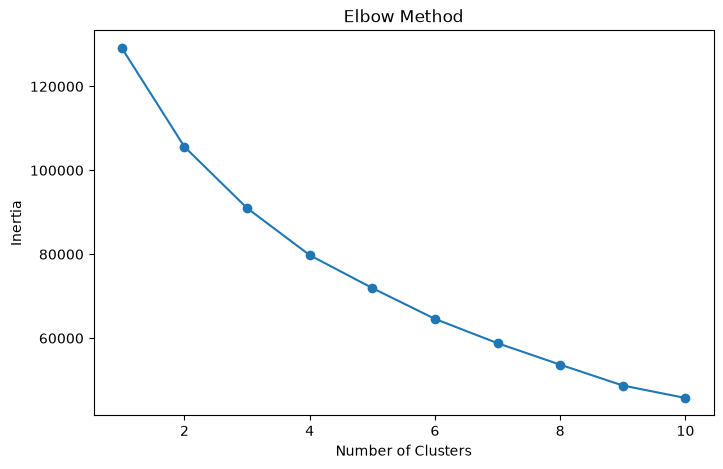

In [5]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels
df["Cluster"] = clusters

df.head()

,u,v,w,x,y,z,Cluster
0,0.56851,0.62783,-0.001017,70.188,17.5,-0.002,0
1,0.56851,0.62783,-0.001017,71.791,17.5,-0.002,0
2,0.56851,0.62783,-0.001017,73.393,17.5,-0.002,0
3,0.87909,0.62783,-0.001017,74.996,17.5,-0.002,0
4,0.56851,0.62783,-0.001017,76.599,17.5,-0.002,0


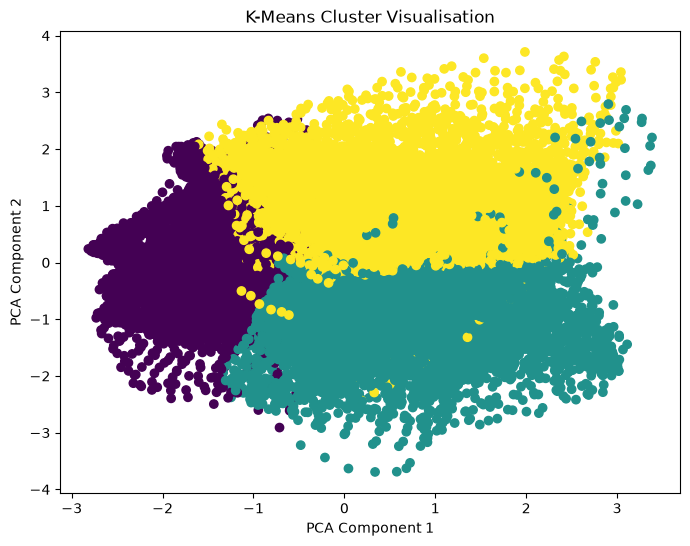

In [7]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)


plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"]
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Cluster Visualisation")

plt.show()

In [9]:
df.columns

Index(['u', 'v', 'w', 'x', 'y', 'z', 'Cluster'], dtype='str')

In [11]:
df.head()

,u,v,w,x,y,z,Cluster
0,0.56851,0.62783,-0.001017,70.188,17.5,-0.002,0
1,0.56851,0.62783,-0.001017,71.791,17.5,-0.002,0
2,0.56851,0.62783,-0.001017,73.393,17.5,-0.002,0
3,0.87909,0.62783,-0.001017,74.996,17.5,-0.002,0
4,0.56851,0.62783,-0.001017,76.599,17.5,-0.002,0


In [12]:
df.to_csv(
    "cone_plot_cluster_results.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!
